# PSET 3 Instructions

**6.8300 Advances in Computer Vision, 2026**  

1. Follow the instructions in this notebook and implement the required functions in the Structure from Motion (SfM) pipeline.
2. Check your solutions with the local autograder: from this directory run `python student_autograder.py`.
3. Submit your completed notebook `1_sfm_pipeline.ipynb` on Gradescope (PSET 3).

---

**Pipeline overview (Structure from Motion)**  
SfM recovers 3D structure and camera poses from multiple 2D images. This notebook builds the pipeline in this order:

- Images
- Part 1 (edges)
- Part 2 (calibration)
- Part 3 (F matrix)
- Part 4 (rectification + matching)
- Part 5 (3D) 


## Part 0: Environment and setup

**Goal:** Ensure your environment and helper code are in place so all run cells below execute correctly.

Run the cell(s) below if you are in a clean environment. Then run the rest of the notebook.

In [7]:
# Install required packages (run once in a clean environment)
%pip install -q numpy opencv-python matplotlib scikit-image Pillow scipy nbformat

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import os
import numpy as np
from pathlib import Path
from PIL import Image, ImageDraw
import cv2
import matplotlib.pyplot as plt
import scipy.ndimage

# Data: try ./data first (handout zip with data inside student_pset3), then ../data (repo layout).
DATA_DIR = Path.cwd() / "data" if (Path.cwd() / "data").exists() else Path.cwd().parent / "data"
OUTPUT_DIR = Path.cwd() / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

# Example paths: DATA_DIR / "p1_edge_identification" / "chessboard.png", DATA_DIR / "p3_fundamental_matrix" / "pts_1.txt", etc.
def load_image(path):
    return np.array(Image.open(path))


def load_points(filename):
    with open(filename) as f:
        lines = f.read().splitlines()
    number_pts = int(lines[0])
    points = np.ones((number_pts, 3))
    for i in range(number_pts):
        split_arr = lines[i + 1].split()
        if len(split_arr) == 2:
            x, y = split_arr
        else:
            x, y, z = split_arr
            points[i, 2] = z
        points[i, 0] = float(x)
        points[i, 1] = float(y)
    return points

### Part 0: helpers functions 

These helpers draw epipolar lines, points, SIFT matches, and 3D point clouds. They are used by the run cells in later parts—you can use them as-is without modifying them.

In [9]:
def draw_points(
    img: np.ndarray, points: np.ndarray, color=(0, 255, 0), radius=5
) -> np.ndarray:
    img_pil = Image.fromarray(img)
    draw = ImageDraw.Draw(img_pil)
    for i in range(points.shape[0]):
        x, y = points[i, 0], points[i, 1]
        draw.ellipse(
            [(x - radius, y - radius), (x + radius, y + radius)], outline=color, width=2
        )
    return np.array(img_pil)


def draw_lines(
    img: np.ndarray, lines: list, color=(255, 0, 0), thickness=3
) -> np.ndarray:
    img_pil = Image.fromarray(img)
    draw = ImageDraw.Draw(img_pil)
    w = img_pil.size[0]
    for m, b in lines:
        draw.line([(0, b), (w, m * w + b)], fill=color, width=thickness)
    return np.array(img_pil)


def get_epipolar_img(img: np.ndarray, lines: list, points: np.ndarray) -> np.ndarray:
    out = draw_lines(img, lines)
    return draw_points(out, points)


def show_epipolar_imgs(
    img1: np.ndarray,
    img2: np.ndarray,
    lines1: list,
    lines2: list,
    pts1: np.ndarray,
    pts2: np.ndarray,
    offset=0,
) -> np.ndarray:
    epi1 = get_epipolar_img(img1, lines1, pts1)
    epi2 = get_epipolar_img(img2, lines2, pts2)
    if offset != 0:
        pad = np.zeros((abs(offset), epi1.shape[1], 3), dtype=epi1.dtype)
        epi2 = np.vstack([pad, epi2]) if offset > 0 else np.vstack([epi2, pad])
        epi1 = np.vstack([epi1, pad]) if offset <= 0 else np.vstack([pad, epi1])
    max_h = max(epi1.shape[0], epi2.shape[0])
    if epi1.shape[0] < max_h:
        epi1 = np.vstack(
            [
                epi1,
                np.zeros((max_h - epi1.shape[0], epi1.shape[1], 3), dtype=epi1.dtype),
            ]
        )
    if epi2.shape[0] < max_h:
        epi2 = np.vstack(
            [
                epi2,
                np.zeros((max_h - epi2.shape[0], epi2.shape[1], 3), dtype=epi2.dtype),
            ]
        )
    combined = np.hstack([epi1, epi2])
    plt.figure(figsize=(12, 5))
    plt.imshow(combined)
    plt.title("Epipolar lines")
    plt.axis("off")
    plt.show()
    return combined


def show_matches(
    img1: np.ndarray, img2: np.ndarray, kp1: list, kp2: list, matches: list
) -> np.ndarray:
    result = cv2.drawMatches(
        img1,
        kp1,
        img2,
        kp2,
        matches,
        None,
        matchColor=(0, 255, 0),
        singlePointColor=(255, 0, 0),
        flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS,
    )
    plt.figure(figsize=(12, 5))
    plt.imshow(result)
    plt.title("SIFT matches")
    plt.axis("off")
    plt.show()
    return result


def show_points_matplotlib(points3D: np.ndarray) -> None:
    fig = plt.figure()
    ax = fig.add_subplot(111, projection="3d")
    ax.scatter(points3D[:, 0], points3D[:, 1], points3D[:, 2], c="r", marker="o", s=5)
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")
    plt.title("3D point cloud")
    plt.show()

## Part 1 — Edge Detection (15 pts)

**Goal:** Prepare for calibration by defining boundaries (contours) in the chessboard image.

**Why contours?** Corners lie on edges; we'll use these boundaries when we detect chessboard corners. Implement contour detection by hand—**do not use OpenCV or similar for contour detection**—to see how boundaries are defined.

**In this part you will:**
- **1.a** — Binarize the image and zero the border so contours are not drawn along the frame.
- **1.b** — Find boundary pixels (contours) by checking 8-neighbors; implement `is_boundary_neighbor`.

---

### 1.a — Image preparation (5 pts)

A binary image separates foreground (chessboard) from background; cleaning the border avoids contours along the image frame.

- **`binarize`:** Set `self.binarized_image` to (H×W) with values in {0, 1} (pixel ≥ 128 → 1).
- **`fill_border`:** Set first/last row and first/last column to 0.

**Before and after (1.a):** Example small image. Use `| - +` to think of the image as a grid; border rows/columns are zeroed so contours are not drawn along the frame.

*Before (grayscale, . = dark &lt; 128, # = light ≥ 128):*

```
+---+---+---+---+---+
| . | . | # | # | . |
+---+---+---+---+---+
| . | # | # | # | # |
+---+---+---+---+---+
| # | # | # | # | # |
+---+---+---+---+---+
| # | # | # | # | . |
+---+---+---+---+---+
| . | . | # | . | . |
+---+---+---+---+---+
```

*After binarize* (pixel ≥ 128 → 1):

```
+---+---+---+---+---+
| 0 | 0 | 1 | 1 | 0 |
+---+---+---+---+---+
| 0 | 1 | 1 | 1 | 1 |
+---+---+---+---+---+
| 1 | 1 | 1 | 1 | 1 |
+---+---+---+---+---+
| 1 | 1 | 1 | 1 | 0 |
+---+---+---+---+---+
| 0 | 0 | 1 | 0 | 0 |
+---+---+---+---+---+
```

*After fill_border* (first/last row and column set to 0):

```
+---+---+---+---+---+
| 0 | 0 | 0 | 0 | 0 |
+---+---+---+---+---+
| 0 | 1 | 1 | 1 | 0 |
+---+---+---+---+---+
| 0 | 1 | 1 | 1 | 0 |
+---+---+---+---+---+
| 0 | 1 | 1 | 1 | 0 |
+---+---+---+---+---+
| 0 | 0 | 0 | 0 | 0 |
+---+---+---+---+---+
```

**Hint:** `np.mean(..., axis=2)` for grayscale; `np.where` for binarization. Complete the `ContourImage` class: `binarize(self)` and `fill_border(self)`.


In [10]:
def get_foreground_components(binary_image: np.ndarray, foreground: int = 1) -> list:
    """Return list of connected components; each component is a list of (row, col) pixels. (Provided.)"""
    num_rows, num_cols = binary_image.shape
    visited = np.zeros_like(binary_image, dtype=bool)
    components = []

    def in_bounds(row, col):
        return 0 <= row < num_rows and 0 <= col < num_cols

    def dfs(row, col):
        stack = [(row, col)]
        component = []
        while stack:
            i, j = stack.pop()
            if visited[i, j]:
                continue
            visited[i, j] = True
            component.append((i, j))
            for dr in (-1, 0, 1):
                for dc in (-1, 0, 1):
                    nr, nc = i + dr, j + dc
                    if (
                        in_bounds(nr, nc)
                        and not visited[nr, nc]
                        and binary_image[nr, nc] == foreground
                    ):
                        stack.append((nr, nc))
        return component

    for r in range(num_rows):
        for c in range(num_cols):
            if not visited[r, c] and binary_image[r, c] == foreground:
                components.append(dfs(r, c))
    return components


class ContourImage:
    def __init__(self, image: Image.Image):
        self.image = image
        self.binarized_image = None

    def binarize(self, threshold=128) -> None:
        np_image = np.array(self.image)

        # TODO: STUDENT CODE HERE (1a)
        raise NotImplementedError
        # END STUDENT CODE

    def fill_border(self) -> None:
        # TODO: STUDENT CODE HERE (1a)
        raise NotImplementedError
        # END STUDENT CODE

    def to_PIL(self) -> Image.Image:
        color_array = np.stack([self.binarized_image] * 3, axis=-1) * 255
        return Image.fromarray(color_array.astype(np.uint8))

    def prepare(self) -> np.ndarray:
        self.binarize()
        self.fill_border()
        return self.binarized_image

### 1.b — Find contours (10 pts)

We want **boundary pixels**: foreground pixels that touch at least one background pixel or the image edge. The functions `get_foreground_components` and the full `find_contours` loop are provided; you implement the helper **`is_boundary_neighbor`**.

---

#### 8-neighborhood

For each foreground pixel at `(i, j)` we check its **8 neighbors** (same as the loop `dr, dc in (-1,0,1)` with `ni = i+dr`, `nj = j+dc`; the center is the current pixel):

```
         col:  j-1    j    j+1
row i-1:   N     N     N
row i:     N     C     N     (C = current pixel at (i,j))
row i+1:   N     N     N
```

---

#### Boundary pixels: before and after (1.b)

A foreground pixel is on the **boundary** if at least one of its 8 neighbors is background (0) or out-of-bounds. Below: **before** = binary image (0/1); **after** = same grid with boundary pixels marked as `B` (foreground pixels that have ≥1 neighbor that is 0 or OOB). Interior foreground pixels stay `1`.

*Before (binary after 1.a):*

```
+---+---+---+---+---+
| 0 | 0 | 1 | 1 | 0 |
+---+---+---+---+---+
| 0 | 1 | 1 | 1 | 1 |
+---+---+---+---+---+
| 1 | 1 | 1 | 1 | 1 |
+---+---+---+---+---+
| 1 | 1 | 1 | 1 | 0 |
+---+---+---+---+---+
| 0 | 0 | 1 | 0 | 0 |
+---+---+---+---+---+
```

*After find_contours* (boundary pixels = contours; marked as B):

```
+---+---+---+---+---+
| 0 | 0 | B | B | 0 |
+---+---+---+---+---+
| 0 | B | 1 | B | B |
+---+---+---+---+---+
| B | 1 | 1 | 1 | B |
+---+---+---+---+---+
| B | B | 1 | B | 0 |
+---+---+---+---+---+
| 0 | 0 | B | 0 | 0 |
+---+---+---+---+---+
```

The result list is the set of `(row, col)` for every `B` (and the center `1` is not in the result).

---

#### Your task: `is_boundary_neighbor`

**Role:** Returns `True` when the neighbor at `(ni, nj)` indicates that the **current** pixel is on the boundary.

**When to return True:**

| Condition | Return |
|-----------|--------|
| `(ni, nj)` is **out-of-bounds** (e.g. `ni < 0`, `ni >= num_rows`, `nj < 0`, `nj >= num_cols`) | `True` |
| `(ni, nj)` is in-bounds and `binary_image[ni, nj] != foreground` | `True` |
| Otherwise (in-bounds and same as foreground) | `False` |

**Logic summary:**  
`is_boundary_neighbor` returns True when:  
**out_of_bounds(ni, nj)** OR **(in_bounds(ni, nj) AND image[ni,nj] != foreground)**

**Hint:** Return `True` when the neighbor is out-of-bounds **or** (when in-bounds) `binary_image[ni, nj] != foreground`. Complete `is_boundary_neighbor` (marked STUDENT CODE HERE).

---

#### Algorithm summary

1. `find_contours` gets foreground components via `get_foreground_components`.
2. For each foreground pixel `(i, j)`, it checks all 8 neighbors with `is_boundary_neighbor`.
3. If **any** neighbor returns `True`, the pixel is a boundary pixel and is added to the result.

Your final output will look similar to the image below.

![Contours on chessboard](../data/figures/find_contours.png)

In [11]:
def is_boundary_neighbor(binary_image, ni, nj, num_rows, num_cols, foreground):
    """Return True when neighbor (ni, nj) indicates the current pixel is on the boundary.
    That is: (ni, nj) is out-of-bounds, or (when in bounds) binary_image[ni, nj] != foreground.
    """
    # TODO: STUDENT CODE HERE (1b)
    raise NotImplementedError
    # END STUDENT CODE


def find_contours(binary_image: np.ndarray, foreground: int = 1) -> list:
    components = get_foreground_components(binary_image, foreground)
    num_rows, num_cols = binary_image.shape
    result = []
    for component in components:
        for i, j in component:
            is_boundary = False
            for dr in (-1, 0, 1):
                for dc in (-1, 0, 1):
                    ni, nj = i + dr, j + dc
                    if is_boundary_neighbor(binary_image, ni, nj, num_rows, num_cols, foreground):
                        is_boundary = True
                        break
                if is_boundary:
                    break
            if is_boundary:
                result.append((i, j))
    return result


def find_chessboard_contours(image: Image.Image) -> list:
    ci = ContourImage(image)
    return find_contours(ci.prepare())

In [12]:
def draw_corners(pil_img, corners, color=(255, 0, 0), radius=5):
    img = pil_img.copy()
    d = ImageDraw.Draw(img)
    for y, x in corners:
        d.ellipse(
            [(x - radius, y - radius), (x + radius, y + radius)], outline=color, width=2
        )
    return img

In [13]:
# Run Part 1: chessboard contours and draw corners
try:
    from PIL import Image

    path = DATA_DIR / "p1_edge_identification" / "chessboard.png"
    img = Image.open(path)
    contours = find_chessboard_contours(img)
    result = draw_corners(img, contours)
    plt.figure(figsize=(8, 5))
    plt.imshow(result)
    plt.title("Chessboard contours")
    plt.axis("off")
    plt.show()
    result.save(OUTPUT_DIR / "p1_corners.png")
except Exception as e:
    err = type(e).__name__
    msg = str(e).split("\n")[0][:80]
    print("Part 1 not fully implemented yet — fix the step below and re-run this cell.")
    print(f"  Error: {err}: {msg}")
    if err == "NotImplementedError":
        print("  → Implement Part 1: ContourImage (binarize, fill_border), find_contours (is_boundary_neighbor), find_chessboard_contours, draw_corners")
    elif "find_chessboard_contours" in str(e) or "draw_corners" in str(e):
        print("  → Implement find_chessboard_contours and/or draw_corners (Part 1).")
    elif "find_contours" in str(e) or "is_boundary" in str(e):
        print("  → Implement find_contours and is_boundary_neighbor (Part 1).")


Part 1 not fully implemented yet — fix the step below and re-run this cell.
  Error: NotImplementedError: 
  → Implement Part 1: ContourImage (binarize, fill_border), find_contours (is_boundary_neighbor), find_chessboard_contours, draw_corners


## Part 2 — Camera Calibration (20 pts)

**Goal:** Recover the camera intrinsics (matrix **K**) and distortion coefficients so we can (1) map 3D points to pixels and (2) **undistort** images—removing lens distortion so that later steps (matching, triangulation) work on idealized pinhole geometry.

We use a known chessboard to get 2D–3D correspondences, then solve for K and distortion. The **code order** below follows this flow:

- **2.a** — Define ideal K and chessboard size (provided).
- **2.b** — Detect 2D corners in the image (provided helpers + run cell). Our provided script will do the camera calibration for you.
- **2.c** — Implement `get_3D_object_points` so we have 3D points for each corner. 
- **2.d** — Implement `distort_point`; with it, the provided `build_undistort_maps` and `undistort_image` produce the undistorted image.



### 2.a — Intrinsic matrix K

**K** maps 3D camera coordinates to 2D pixels (focal lengths + principal point). We recover the real K from calibration and use it for projection and undistortion in (2.d). 

Below: ideal K (45° FOV) and `chessboard_size`—**no code to write**; run the cell to display them.

![Intrinsic matrix K](../data/figures/IntrinsicMatrix.png)


In [14]:
# 2.a — Ideal intrinsic matrix K and chessboard size (provided)
fov_rad = np.deg2rad(45)
f_r = 1.0 / (2 * np.tan(fov_rad / 2))
ideal_intrinsic_matrix = np.array(
    [[f_r * min(640, 480), 0, 640 / 2], [0, f_r * min(640, 480), 480 / 2], [0, 0, 1]],
    dtype=np.float64,
)
chessboard_size = (16, 9)  # inner corners (cols, rows); must match chessboard.png
print("Ideal K (2.a):")
print(ideal_intrinsic_matrix)
print("chessboard_size (inner corners):", chessboard_size)

Ideal K (2.a):
[[579.41125497   0.         320.        ]
 [  0.         579.41125497 240.        ]
 [  0.           0.           1.        ]]
chessboard_size (inner corners): (16, 9)


### 2.b — Find corners

- OpenCV finds the **inner corners** of the chessboard (where four squares meet).
- These are the **2D image measurements** we need for calibration: paired with 3D object points (2.c), they let us solve for K and distortion, then undistort in 2.d.
- `chessboard_size` is (number of inner corners in x, number in y)—one less than the number of squares per side.

**Inner corners only** (example 2×2 inner corners = 3×3 squares):

```
+-------+-------+-------+
|       |       |       |
|   +---+---+---+---+   |     + = inner corner (detected)
+---+   |   |   |   +---+
|       |   |   |       |
+---+   +---+---+   +---+
|       |       |       |
|   +---+---+---+---+   |
+-------+-------+-------+
```

**Run the next two cells** to load the corner-finding helpers and visualize detected corners on the chessboard image.

![Find corners on chessboard](../data/figures/find_corners.png)


In [15]:
# 2.b — Helpers to find and refine chessboard corners (provided)
def load_grayscale_image(image):
    return np.mean(image, axis=2).astype(np.uint8)


def find_chessboard_corners(image, chessboard_size):
    ret, corners = cv2.findChessboardCorners(image, chessboard_size, None)
    if not ret:
        raise ValueError("Verify correct dimensions of chessboard")
    return corners


def refine_corners(image, corners):
    return cv2.cornerSubPix(
        image,
        corners,
        (11, 11),
        (-1, -1),
        (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001),
    )

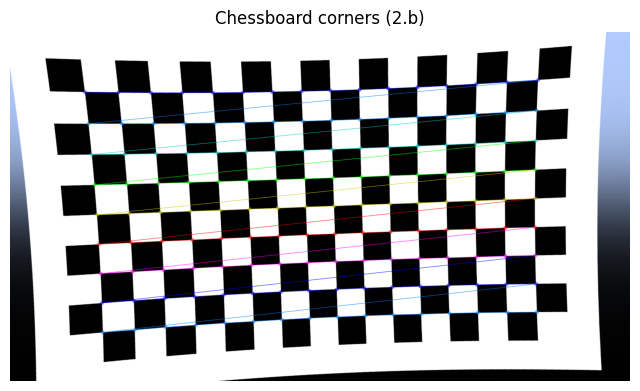

In [16]:
# Run 2.b: find corners on the chessboard image and visualize
try:
    path = DATA_DIR / "p1_edge_identification" / "chessboard.png"
    image = load_image(path)
    gray = load_grayscale_image(image)
    corners = find_chessboard_corners(gray, chessboard_size)
    corners = refine_corners(gray, corners)
    corners_img = image.copy()
    cv2.drawChessboardCorners(corners_img, chessboard_size, corners, True)
    plt.figure(figsize=(8, 5))
    plt.imshow(corners_img)
    plt.title("Chessboard corners (2.b)")
    plt.axis("off")
    plt.show()
except Exception as e:
    err = type(e).__name__
    msg = str(e).split("\n")[0][:80]
    print("2.b (find corners) failed — fix and re-run this cell.")
    print(f"  Error: {err}: {msg}")
    if "chessboard" in str(e).lower() and "Verify" in str(e):
        print("  → Check chessboard_size in 2.a matches the image (e.g. (16, 9)).")
    elif "not found" in str(e).lower() or "No such file" in str(e):
        print("  → Ensure DATA_DIR points to data/ and chessboard.png exists under p1_edge_identification/.")


### 2.c — 3D object points

We need **3D coordinates** for each detected corner so we can calibrate: with 2D corners from 2.b and these 3D object points, we solve for K and the distortion coefficients, then use them in 2.d to undistort. The chessboard is flat, so every point has **z = 0**. The ordering of points must match OpenCV’s corner order (e.g. left-to-right, top-to-bottom).

---

#### Before and after

| Stage | What you have |
|-------|----------------|
| **Before** | 2D corner positions from OpenCV (one per inner corner). |
| **After** | Same ordering, but each row is (x, y, 0) in object space. |

Output shape: **(N, 3)** with **N = cols × rows** (e.g. `chessboard_size = (2, 2)` → 4 points).

---

#### Object-space grid (example)

For **2×2 inner corners** (cols=2, rows=2), object points in a flat grid:

```text
+-----------+-----------+
| (0,0,0)   | (1,0,0)   |   row 0
+-----------+-----------+
| (0,1,0)   | (1,1,0)   |   row 1
+-----------+-----------+
  col 0       col 1

z = 0 for all. Order matches OpenCV (e.g. row-major).
```

Your function returns an array of shape (N, 3) in this order.

---

#### Your task

Implement **`get_3D_object_points(chessboard_size)`** so that:

- `chessboard_size` is (number of inner corners in x, number in y).
- Fill `object_points` with (x, y, 0) in the same order OpenCV uses for corners.

**Hint:** `np.mgrid` or a double loop over the grid; output shape (N, 3) with N = cols × rows.


In [17]:
def get_3D_object_points(chessboard_size):
    object_points = np.zeros((chessboard_size[0] * chessboard_size[1], 3), np.float32)

    # TODO: STUDENT CODE HERE (2c)
    raise NotImplementedError
    # END STUDENT CODE

### 2.d — Undistortion

With **K** and **distortion coefficients** from calibration (2.a–2.c), we can now produce an undistorted image. **Goal:** Remove lens distortion so the image obeys the pinhole model. Real lenses introduce **radial** (and sometimes **tangential**) distortion. We use the calibrated coefficients to build an inverse map: for each pixel in the **output** (undistorted) image, we find where it came from in the **distorted** image and sample there. The provided code does the mapping; you implement the **forward distortion** model **`distort_point`**.

**Why implement "distort"?** To know *where to sample* in the distorted image for each output pixel, we take the ideal (undistorted) normalized coordinates and apply the **forward** distortion formula—that gives the corresponding location in the distorted image. So the one function you implement is the distortion model; the rest of the pipeline uses it to produce the undistorted result.

---

#### Pipeline (what the provided code does)

For each **output** pixel (u, v) in the undistorted image, one straight flow (top to bottom):

```text
+------------------------------------------+
|  output pixel (u, v)                     |
+------------------------------------------+
                    |
                    v
+------------------------------------------+
|  1. Normalize                            |
|     (x_norm, y_norm) = ((u-cx)/fx, ...)  |
+------------------------------------------+
                    |
                    v
+------------------------------------------+
|  2. Distort  <-- YOU IMPLEMENT THIS      |
|     (x_dist, y_dist) = distort_point(...)|
+------------------------------------------+
                    |
                    v
+------------------------------------------+
|  3. Map (x_dist, y_dist) to pixel;      |
|     sample original image there          |
+------------------------------------------+
```

So you only implement **`distort_point`**; **`build_undistort_maps`** and **`undistort_image`** are provided.

---

#### Your task: `distort_point` (used to build the undistort map)

Implement **`distort_point(x_norm, y_norm, k1, k2, p1, p2, k3)`** so that it returns **(xd, yd)** using the OpenCV model.

**Radial distortion** (use normalized coordinates $x$, $y$):

$$r^2 = x^2 + y^2, \qquad \text{radial} = 1 + k_1 r^2 + k_2 r^4 + k_3 r^6$$

(Here $r^4$ and $r^6$ are the second and third powers of $r^2$.)

**Tangential distortion** (add these to the radially distorted coordinates):

$$x_d = x \cdot \text{radial} + 2 p_1 x y + p_2 (r^2 + 2 x^2)$$

$$y_d = y \cdot \text{radial} + p_1 (r^2 + 2 y^2) + 2 p_2 x y$$

**Hints:**
- Coefficient order in OpenCV: (k₁, k₂, p₁, p₂, k₃). Use the inputs `x_norm`, `y_norm` as $x$ and $y$ in the formulas above.
- Compute $r^2$ first from the normalized coordinates; then compute the radial factor (it depends only on $r^2$ and the $k$'s).
- Each of $x_d$ and $y_d$ is the coordinate times the radial factor, plus two tangential terms—the docstring in the code cell spells out exactly which terms go into $x_d$ vs $y_d$.
- The rest of the pipeline is provided; you only need to implement `distort_point`.

![Distortion coefficients](../data/figures/distortions.png)


In [ ]:
def calibrate_camera(object_points, corners, image_size):
    """Solve for K and distortion from 2D–3D correspondences. (Provided.)"""
    ret, camera_matrix, dist_coeffs, rvecs, tvecs = cv2.calibrateCamera(
        [object_points], [corners], image_size, None, None
    )
    return camera_matrix, dist_coeffs


def distort_point(x_norm, y_norm, k1, k2, p1, p2, k3=0.0):
    """
    Apply radial and tangential distortion to normalized coordinates.
    Used by build_undistort_maps to find where to sample in the distorted image
    for each output pixel (so the pipeline produces an undistorted image).
    Returns (xd, yd).

    OpenCV model (use x_norm as x, y_norm as y):
      r2 = x^2 + y^2
      radial = 1 + k1*r2 + k2*r2^2 + k3*r2^3
      xd = x*radial + 2*p1*x*y + p2*(r2 + 2*x^2)
      yd = y*radial + p1*(r2 + 2*y^2) + 2*p2*x*y

    Hint: compute r2 first, then radial, then xd and yd (each has one radial
    term and two tangential terms as above).
    """

    # TODO: STUDENT CODE HERE (2d)
    raise NotImplementedError
    # END STUDENT CODE


def build_undistort_maps(h, w, camera_matrix, dist_coeffs):
    """Build mapx, mapy so that remapping gives undistorted image. (Provided.)"""
    fx, fy = camera_matrix[0, 0], camera_matrix[1, 1]
    cx, cy = camera_matrix[0, 2], camera_matrix[1, 2]
    dc = dist_coeffs.ravel()
    k1, k2, p1, p2 = dc[0], dc[1], dc[2], dc[3]
    k3 = dc[4] if len(dc) > 4 else 0.0
    mapx = np.zeros((h, w), np.float32)
    mapy = np.zeros((h, w), np.float32)
    for v in range(h):
        for u in range(w):
            x_norm = (u - cx) / fx
            y_norm = (v - cy) / fy
            xd, yd = distort_point(x_norm, y_norm, k1, k2, p1, p2, k3)
            mapx[v, u] = fx * xd + cx
            mapy[v, u] = fy * yd + cy
    return mapx, mapy


def undistort_image(image, camera_matrix, dist_coeffs):
    """Remap image using inverse distortion; uses build_undistort_maps and map_coordinates. (Provided.)"""
    h, w = image.shape[:2]
    mapx, mapy = build_undistort_maps(h, w, camera_matrix, dist_coeffs)
    channels = [
        scipy.ndimage.map_coordinates(
            image[..., c],
            np.vstack([mapy.ravel(), mapx.ravel()]),
            order=1,
            mode="constant",
            cval=0.0,
        ).reshape(h, w)
        for c in range(image.shape[2])
    ]
    return np.dstack(channels).astype(np.uint8)

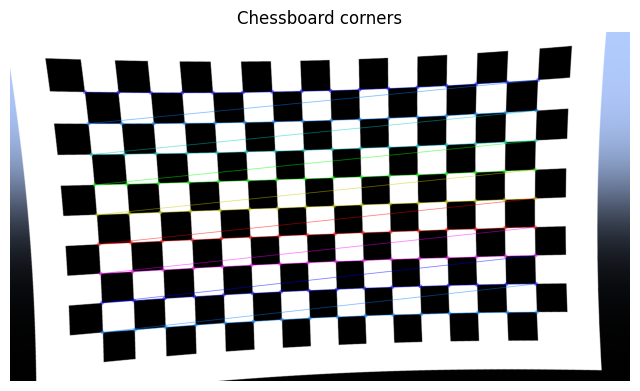

Part 2 not fully implemented yet — fix the step below and re-run this cell.
  Error: NotImplementedError: 
  → Implement 2.c: get_3D_object_points(chessboard_size)
  → Implement 2.d: distort_point(x_norm, y_norm, k1, k2, p1, p2, k3)


In [19]:
# Run Part 2: calibrate camera and undistort
try:
    path = DATA_DIR / "p1_edge_identification" / "chessboard.png"
    image = load_image(path)
    gray = load_grayscale_image(image)
    corners = find_chessboard_corners(gray, chessboard_size)
    corners = refine_corners(gray, corners)
    corners_img = image.copy()
    cv2.drawChessboardCorners(corners_img, chessboard_size, corners, True)
    plt.figure(figsize=(8, 5))
    plt.imshow(corners_img)
    plt.title("Chessboard corners")
    plt.axis("off")
    plt.show()
    object_points = get_3D_object_points(chessboard_size)
    camera_matrix, dist_coeffs = calibrate_camera(
        object_points, corners, gray.shape[::-1]
    )
    undistorted = undistort_image(image, camera_matrix, dist_coeffs)
    plt.figure(figsize=(8, 5))
    plt.imshow(undistorted)
    plt.title("Undistorted image")
    plt.axis("off")
    plt.show()
    Image.fromarray(undistorted).save(OUTPUT_DIR / "p2_undistorted.png")
except Exception as e:
    err = type(e).__name__
    msg = str(e).split("\n")[0][:80]
    print("Part 2 not fully implemented yet — fix the step below and re-run this cell.")
    print(f"  Error: {err}: {msg}")
    if err == "NotImplementedError":
        print("  → Implement 2.c: get_3D_object_points(chessboard_size)")
        print("  → Implement 2.d: distort_point(x_norm, y_norm, k1, k2, p1, p2, k3)")
    else:
        if "get_3D_object_points" in str(e):
            print("  → Implement 2.c: get_3D_object_points(chessboard_size)")
        if "distort_point" in str(e) or "undistort" in str(e).lower():
            print("  → Implement 2.d: distort_point(x_norm, y_norm, k1, k2, p1, p2, k3)")
    if "chessboard" in str(e).lower() and "Verify" in str(e):
        print("  → Check that chessboard_size in 2.a matches the image (e.g. (16, 9)).")


## Part 3 — Epipolar Geometry (20 pts)

From two views and point correspondences, compute the fundamental matrix **F** and the epipolar lines. A point in one image has its match on a line in the other—the **epipolar line**; F encodes this constraint.

![Epipolar geometry](../data/figures/epipolar_diagram.png)


### 3.a — Least-squares eight-point algorithm

**Goal:** Compute the fundamental matrix **F** from point correspondences (p, p') between two images. Each correspondence satisfies the epipolar constraint $\mathbf{p}'^\top F \mathbf{p} = 0$, which is one linear equation in the 9 entries of F. With 8 or more correspondences we can solve for F (up to scale). F must have rank 2; the provided **`enforce_rank2(F)`** enforces this after you form F.

---

#### Setting up the linear system

Stack the unknowns into a 9-vector **f** (e.g. row-major order of F). Then all constraints become **W f = 0**, where **W** is N×9: one row per correspondence.

For point $(u, v, 1)$ in image 1 and $(u', v', 1)$ in image 2, expanding $\mathbf{p}'^\top F \mathbf{p} = 0$ gives one row of W:

$$\text{row} = [\, u'u,\ u'v,\ u',\ v'u,\ v'v,\ v',\ u,\ v,\ 1\,]$$

So **W** is N×9; each row encodes one equation in the 9 unknowns.

---

#### Solving W f = 0

The solution **f** lies in the **null space** of W. With 8 points the null space is 1D (unique up to scale); with more points, use the direction that best satisfies the equations (minimum singular value). Reshape the 9-vector to a 3×3 matrix to get F, then return **`enforce_rank2(F)`**.

**Hints (without giving the answer):** Build the N×9 matrix W from `points1` and `points2` using the row form above. Use **`np.linalg.svd`** on W; the null-space vector corresponds to a specific singular value. Reshape that vector to 3×3 and pass the result to `enforce_rank2`.

---

**Your task:** Implement **`lstsq_eight_point_alg(points1, points2)`** returning a 3×3 fundamental matrix F.


In [20]:
def enforce_rank2(F):
    """Given 3×3 F, return rank-2 F by zeroing the smallest singular value. (Provided.)"""
    U, s, Vh = np.linalg.svd(F)
    s[-1] = 0
    return U.dot(np.diag(s)).dot(Vh)


def normalize_points(points):
    """
    Normalize so centroid is at origin and mean distance to origin is sqrt(2).
    points: (N, 3) homogeneous. Returns (normalized_points (N,3), T (3,3)).
    """
    mean = np.mean(points, axis=0)
    pts_centered = points - mean
    scale = np.sqrt(2) / np.mean(np.sqrt(np.sum(pts_centered[:, :2] ** 2, axis=1)))
    T = np.array(
        [[scale, 0, -scale * mean[0]], [0, scale, -scale * mean[1]], [0, 0, 1]]
    )
    normalized = (T.dot(points.T)).T
    return normalized, T


def lstsq_eight_point_alg(points1, points2):
    # TODO: STUDENT CODE HERE (3a)
    # Build the N×9 matrix from point correspondences, solve for F (e.g. via SVD), enforce rank 2, and return F.
    raise NotImplementedError
    # END STUDENT CODE

### 3.b — Normalized eight-point algorithm

**Goal:** Improve numerical stability by normalizing point coordinates before solving for F, then converting the result back to the original coordinate system. Normalization: translate so the centroid is at the origin and scale so the mean distance to the origin is $\sqrt{2}$.

---

#### Pipeline

- Normalize **points1** and **points2** using the provided **`normalize_points(points)`**, which returns `(normalized_points, T)` where T is the 3×3 transformation matrix.
- Run your **`lstsq_eight_point_alg`** on the normalized point sets to get **F_norm** (fundamental matrix in normalized coordinates).
- **Denormalize:** The fundamental matrix in the original coordinates is related to F_norm by the normalization matrices T₁ and T₂. The formula is $F = T_2^\top F_{\text{norm}} T_1$ (so that the constraint $\mathbf{p}'^\top F \mathbf{p} = 0$ holds when points are transformed by T₁ and T₂).

**Flow:**

- Normalize points1 to get (p1_norm, T1); normalize points2 to get (p2_norm, T2).
- Compute F_norm = lstsq_eight_point_alg(p1_norm, p2_norm).
- Combine F_norm with T1 and T2 to obtain F in original coordinates.

**Hints:** Use the provided `normalize_points` for each set. Call your 3.a implementation on the normalized points. Denormalize using the two matrices returned by `normalize_points` and the formula above.

---

**Your task:** Implement **`normalized_eight_point_alg(points1, points2)`** returning a 3×3 fundamental matrix F in original coordinates.


In [ ]:
def normalized_eight_point_alg(points1, points2):
    # TODO: STUDENT CODE HERE (3b)
    raise NotImplementedError
    # END STUDENT CODE

### 3.c — Epipolar lines

**Goal:** For each point **p** in one image, the corresponding **epipolar line** in the other image is $\mathbf{l} = F \mathbf{p}$. The drawing helper **`draw_lines`** expects each line in slope–intercept form $y = mx + b$, i.e. a pair **(m, b)**.

---

#### From F and p to line l

- Compute $\mathbf{l} = F \mathbf{p}$ for all points at once: **l = F @ points.T** gives a **(3, N)** array (one column per point). Each column is $[A, B, C]^\top$.
- The line in the image is the set of $(x, y)$ satisfying **Ax + By + C = 0**.
- Convert to **y = mx + b** when **B ≠ 0**: $m = -A/B$, $b = -C/B$.
- When **B ≈ 0** the line is (nearly) vertical. **`draw_lines`** still expects **(m, b)** for every line—use a consistent convention (e.g. a sentinel for m or a special (m, b)) that **`draw_lines`** can interpret (check its docstring).

#### Pseudocode

```
l = F @ points.T   # (3, N): each column is (A, B, C) for one point
out = []
for i in range(N):
    A, B, C = l[0,i], l[1,i], l[2,i]
    if abs(B) > EPS:
        m = -A / B
        b = -C / B
        out.append((m, b))
    else:
        # vertical or near-vertical: choose (m, b) so draw_lines draws correctly
        out.append(...)
return out
```

---

**Your task:** Implement **`compute_epipolar_lines(points, F)`** returning a list of **(m, b)** pairs, one per point.

![Epipolar lines test](../data/figures/epipolar_test.png)


In [3]:
def compute_epipolar_lines(points, F):
    # TODO: STUDENT CODE HERE (3c)
    raise NotImplementedError


def compute_distance_to_epipolar_lines(points1, points2, F):
    l = F.T.dot(points2.T)
    return np.mean(
        np.abs(np.sum(l * points1.T, axis=0)) / np.sqrt(l[0, :] ** 2 + l[1, :] ** 2)
    )

In [23]:
# Run Part 3: fundamental matrix and epipolar lines
try:
    p3_dir = DATA_DIR / "p3_fundamental_matrix"
    pts1 = load_points(p3_dir / "pts_1.txt")
    pts2 = load_points(p3_dir / "pts_2.txt")
    im1 = load_image(p3_dir / "const_im1.png")
    im2 = load_image(p3_dir / "const_im2.png")
    F_lls = lstsq_eight_point_alg(pts1, pts2)
    F_norm = normalized_eight_point_alg(pts1, pts2)
    d1 = compute_distance_to_epipolar_lines(pts1, pts2, F_norm)
    d2 = compute_distance_to_epipolar_lines(pts2, pts1, F_norm.T)
    print("Mean distance to epipolar lines (im1):", d1, "(im2):", d2)
    lines1 = compute_epipolar_lines(pts2, F_norm.T)
    lines2 = compute_epipolar_lines(pts1, F_norm)
    show_epipolar_imgs(im1, im2, lines1, lines2, pts1, pts2)
except Exception as e:
    err = type(e).__name__
    msg = str(e).split("\n")[0][:80]
    print("Part 3 not fully implemented yet — fix the step below and re-run this cell.")
    print(f"  Error: {err}: {msg}")
    if err == "NotImplementedError":
        print("  → Implement 3.a: lstsq_eight_point_alg and normalized_eight_point_alg")
        print("  → Implement 3.b: compute_distance_to_epipolar_lines")
        print("  → Implement 3.c: compute_epipolar_lines")
    else:
        if "lstsq" in str(e) or "eight_point" in str(e) or "normalized" in str(e):
            print("  → Implement lstsq_eight_point_alg and/or normalized_eight_point_alg (3.a)")
        if "distance" in str(e) or "epipolar" in str(e):
            print("  → Implement compute_distance_to_epipolar_lines (3.b) and compute_epipolar_lines (3.c)")


Part 3 not fully implemented yet — fix the step below and re-run this cell.
  Error: NotImplementedError: 
  → Implement 3.a: lstsq_eight_point_alg and normalized_eight_point_alg
  → Implement 3.b: compute_distance_to_epipolar_lines
  → Implement 3.c: compute_epipolar_lines


## Part 4 — Image Rectification (15 pts)

**Goal:** Warp the two images so that **epipolar lines become horizontal scanlines**. Then corresponding points lie on the same row and stereo matching reduces to a 1D search along rows.

**Flow:**

- 4.a — compute the **epipole** in each image (where all epipolar lines meet)
- 4.b — compute two **homographies** H₁, H₂ so that in the rectified images epipolar lines are horizontal
- 4.c — **warp** each image by the corresponding homography to get the rectified pair
- 4.d — **feature matching** (SIFT + FLANN) to find correspondences automatically for use in Part 5

![Rectified stereo pair](../data/figures/rectified.png)


### 4.a — Epipole

**Goal:** The **epipole** in one image is the point where all epipolar lines from the other image meet (it is the projection of the other camera center). We need to compute it from F and the point correspondences.

**Geometry:** In image 2, every epipolar line coming from a point in image 1 passes through the same point **e₂** (the epipole in image 2):

```
    \    |    /
     \   |   /
      \  |  /
       \ | /
        \|/
  -------e-------   e = epipole
        /|\
       / | \
      /  |  \
```

**Setting up the problem:**

- For points **p'** in image 2, the epipolar lines in image 1 are $\mathbf{l} = F^\top \mathbf{p}'$ (one line per point).
- The epipole **e** in image 1 lies on every such line, so $\mathbf{l}^\top \mathbf{e} = 0$ for every line.
- Stack the lines as rows into a matrix **L**; then **L e = 0**, so **e** is in the null space of L.
- Solve for **e** (e.g. via SVD of L); the solution is unique up to scale.
- **Normalize** so the third coordinate is 1 (homogeneous coordinates).

**Hints:**

- Build **L** with one row per point in the *other* image: for each point **p'** in `points2`, compute $\mathbf{l} = F^\top \mathbf{p}'$ and append **l** as a row. Use matrix multiplication (e.g. **`F.T @ points2.T`** if `points2` is N×3) so that each column is a line; then take **L = that result.T** so each *row* is a line (L is N×3).
- The epipole **e** is the right singular vector corresponding to the **smallest** singular value of **L**. Use **`np.linalg.svd(L)`**; the rows of **Vh** are the right singular vectors, so the last row of **Vh** (index -1) is the null-space direction. Extract it and reshape to a 3-vector.
- Normalize **e** so the third coordinate is 1: divide by **e[2]** (e.g. **`e = e / e[2]`**). Return as a 1D array of shape (3,) with last entry 1.

---

**Your task:** Implement **`compute_epipole(points1, points2, F)`** returning the epipole in image 1 as a 3-vector (e.g. shape (3,) or (3,1)) with last coordinate 1.


In [ ]:
def build_H2_rectification(e2, height, width):
    """
    Build H2 so that the epipole in image 2 goes to infinity on the x-axis.
    Translate to center, rotate epipole to x-axis, then projective map to infinity. (Provided.)
    """
    h, w = height, width
    T = np.array([[1, 0, -w / 2], [0, 1, -h / 2], [0, 0, 1]])
    e2p = (T.dot(e2) / e2[2]).copy()
    e2p[2] = 1
    e2x, e2y = e2p[0], e2p[1]
    a = 1 if e2x >= 0 else -1
    denom = np.sqrt(e2x**2 + e2y**2)
    R1 = a * e2x / denom
    R2 = a * e2y / denom
    R = np.array([[R1, R2, 0], [-R2, R1, 0], [0, 0, 1]])
    e2p = R.dot(e2p)
    f = e2p[0]
    G = np.array([[1, 0, 0], [0, 1, 0], [-1 / f, 0, 1]])
    H2 = np.linalg.inv(T).dot(G).dot(R).dot(T)
    return H2


def warp_image_with_inverse_map(im, mapx, mapy):
    """Remap image using mapx, mapy (source coords for each output pixel). (Provided.)"""
    channels = [
        scipy.ndimage.map_coordinates(
            im[..., c],
            np.vstack([mapy.ravel(), mapx.ravel()]),
            order=1,
            mode="constant",
            cval=0.0,
        ).reshape(mapx.shape)
        for c in range(im.shape[2])
    ]
    return np.dstack(channels).astype(np.uint8)


def compute_epipole(points1, points2, F):
    # TODO: STUDENT CODE HERE (4a)
    raise NotImplementedError
    # END STUDENT CODE

### 4.b — Matching homographies

**Goal:** Compute two homographies **H₁** and **H₂** so that when we warp the two images by them, **epipolar lines become horizontal** (corresponding points lie on the same row).

---

#### Strategy

- **H₂ (image 2):** Map the image so that the **epipole e₂** goes to a point at **infinity** in the horizontal direction (e.g. $(1, 0, 0)^\top$ in homogeneous coordinates). Then all epipolar lines in the rectified image 2 become horizontal. The provided **`build_H2_rectification(e2, height, width)`** returns an H₂ that does this (translate to center, rotate so epipole aligns with x-axis, then a projective step that sends it to infinity).

- **H₁ (image 1):** Choose H₁ so that the **fundamental constraint** still holds in the rectified space: corresponding points in the two rectified images must satisfy the new fundamental matrix induced by H₁ and H₂. Use the point correspondences **(points1, points2)** and **F** to set up linear constraints on the entries of H₁; then solve (e.g. least-squares) for H₁. The rectified correspondence condition (same row, etc.) gives the constraints.

**Hints:** Get H₂ from `build_H2_rectification(e2, im2.shape[0], im2.shape[1])`. For H₁, express the constraint that rectified points are in correspondence (using F, e2, and the known form of H₂); you get a linear system in the entries of H₁. Solve with `np.linalg.lstsq` or similar. Return (H1, H2) as 3×3 matrices.

---

**Your task:** Implement **`compute_matching_homographies(e2, F, im2, points1, points2)`** returning (H1, H2).


In [ ]:
def compute_matching_homographies(e2, F, im2, points1, points2):
    # TODO: STUDENT CODE HERE (4b)
    raise NotImplementedError
    # END STUDENT CODE

### 4.c — Rectified image

**Goal:** Warp a single image by a homography **H** to produce the **rectified** image. We fill the *output* image by **inverse mapping**: for each output pixel, find which *input* pixel it came from using $H^{-1}$, then sample the input there (the provided helper does the sampling with interpolation).

---

#### Inverse mapping

- **Output pixel (u, v)** comes from the point in the input image at $\mathbf{p}_{src} = H^{-1} (u, v, 1)^\top$. In homogeneous form $(x, y, w)$, the source coordinates are **(x/w, y/w)**.
- The provided **`warp_image_with_inverse_map(im, mapx, mapy)`** does the sampling. It expects two arrays **mapx**, **mapy** (same shape as the desired output) such that **output[v, u] = sample of im at (mapx[v,u], mapy[v,u])**. So for each output index (v, u), set **mapx[v,u] = x/w** and **mapy[v,u] = y/w** from $H^{-1}(u, v, 1)^\top$.

#### Output size and offset

- The rectified image can have a different size than the input. A simple approach: transform the **four corners** of the input image by **H** to get their positions in the *output* (rectified) space; take the **bounding box** of those four points to get the output width, height, and **offset (offset_x, offset_y)** (e.g. the min x and min y of the box).
- Build a grid of output coordinates (u, v) covering that box. For each (u, v), apply $H^{-1}$ to get source (x/w, y/w) and store in **mapx**, **mapy**. Call **`warp_image_with_inverse_map(im, mapx, mapy)`** to get the rectified image.

#### Return value

Return **(rectified_image, (offset_x, offset_y))** so the caller can align the two rectified images. **offset_x**, **offset_y** are the origin of your output grid in the rectified coordinate system (e.g. the left and top of the bounding box).

---

**Your task:** Implement **`compute_rectified_image(im, H)`** returning **(rectified_image, (offset_x, offset_y))**.


In [ ]:
def compute_rectified_image(im, H):
    # TODO: STUDENT CODE HERE (4c)
    raise NotImplementedError
    # END STUDENT CODE

### 4.d — Feature detection (SIFT + FLANN)

**Goal:** Automatically find **point correspondences** between two images (keypoints + descriptors, then matching). These matches will be used in Part 5 to estimate F and recover pose. You will use **SIFT** for detection/description and **FLANN** for matching, with a **ratio test** to filter weak matches.

---

#### Pipeline

1. **Detect and describe:** Run a **SIFT** detector/descriptor on both images to get keypoints and their descriptors (e.g. 128-dimensional vectors per keypoint). OpenCV provides a SIFT implementation.
2. **Match:** Use a **FLANN**-based matcher (fast approximate nearest neighbors) to find candidate matches between descriptors. For each keypoint in image 1, get the two nearest neighbors in image 2.
3. **Ratio test:** Keep a match only if the distance to the nearest neighbor is sufficiently smaller than the distance to the second nearest (e.g. ratio threshold **0.75**). This rejects many ambiguous matches.
4. Return **(kp1, kp2, good_matches)** in the format expected by the run cell and by Part 5 (e.g. keypoints as lists and matches as a list of `cv2.DMatch` or similar).

**Hints:** Create a SIFT object to detect and compute descriptors on both images. Build a FLANN index from the descriptors of one image and search with the other; apply the ratio test (0.75) to obtain a list of good matches. Return keypoints and matches in the type/shape that the rest of the pipeline expects (check the run cell or Part 5 for the expected format).

---

**Your task:** Implement **`find_matches(img1, img2)`** returning (kp1, kp2, good_matches).


In [ ]:
def find_matches(img1, img2):
    # TODO: STUDENT CODE HERE (4d)
    raise NotImplementedError
    # END STUDENT CODE

In [28]:
# Run Part 4: rectification and optional SIFT matches
try:
    p3_dir = DATA_DIR / "p3_fundamental_matrix"
    pts1 = load_points(p3_dir / "pts_1.txt")
    pts2 = load_points(p3_dir / "pts_2.txt")
    im1 = load_image(p3_dir / "const_im1.png")
    im2 = load_image(p3_dir / "const_im2.png")
    F = normalized_eight_point_alg(pts1, pts2)
    e1 = compute_epipole(pts1, pts2, F)
    e2 = compute_epipole(pts2, pts1, F.T)
    H1, H2 = compute_matching_homographies(e2, F, im2, pts1, pts2)
    rect1, off1 = compute_rectified_image(im1, H1)
    rect2, off2 = compute_rectified_image(im2, H2)
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(rect1)
    plt.title("Rectified 1")
    plt.axis("off")
    plt.subplot(1, 2, 2)
    plt.imshow(rect2)
    plt.title("Rectified 2")
    plt.axis("off")
    plt.show()
    kp1, kp2, good_matches = find_matches(im1, im2)
    show_matches(im1, im2, kp1, kp2, good_matches)
except Exception as e:
    err = type(e).__name__
    msg = str(e).split("\n")[0][:80]
    print("Part 4 not fully implemented yet — fix the step below and re-run this cell.")
    print(f"  Error: {err}: {msg}")
    if err == "NotImplementedError":
        print("  → Implement 4.a: compute_epipole")
        print("  → Implement 4.b: compute_matching_homographies")
        print("  → Implement 4.c: compute_rectified_image")
        print("  → Implement 4.d: find_matches")
    else:
        if "epipole" in str(e):
            print("  → Implement compute_epipole (4.a)")
        if "homograph" in str(e).lower() or "matching" in str(e):
            print("  → Implement compute_matching_homographies (4.b)")
        if "rectif" in str(e).lower():
            print("  → Implement compute_rectified_image (4.c)")
        if "find_matches" in str(e) or "match" in str(e).lower():
            print("  → Implement find_matches (4.d)")


Part 4 not fully implemented yet — fix the step below and re-run this cell.
  Error: NotImplementedError: 
  → Implement 4.a: compute_epipole
  → Implement 4.b: compute_matching_homographies
  → Implement 4.c: compute_rectified_image
  → Implement 4.d: find_matches


## Part 5 — 3D Reconstruction (30 pts)

**Goal:** From two **calibrated** views and point correspondences, compute the **relative camera pose (R, T)** and **triangulate** to get a 3D point cloud. The pipeline: estimate **F** from matches (with RANSAC), convert to the **essential matrix E** using K, decompose E into **candidate (R, T)** pairs, pick the correct one using **cheirality** (points must be in front of both cameras), then form **projection matrices** and triangulate.

**Flow:**

- 5.a — **F** from matches (RANSAC)
- 5.b — **E = Kᵀ F K**
- 5.c — **Four (R, T) candidates** from E via SVD
- 5.d — **Best (R, T)** by cheirality
- 5.e — **P₁, P₂** and triangulation

![SIFT matching](../data/figures/sift.png)


### 5.a — Fundamental matrix from matches

**Goal:** Estimate the **fundamental matrix F** from matched keypoints in two images. Matches from SIFT/FLANN contain **outliers**; use **RANSAC** (or an equivalent robust method) so that outliers do not dominate the estimate. OpenCV provides a function that estimates F from point pairs with a RANSAC option.

---

#### Pipeline

1. Convert keypoints and matches into two **N×2** arrays of point coordinates **(pts1, pts2)** (one row per match). The provided **`points_from_matches(kp1, kp2, good_matches)`** does this and returns (pts1, pts2) as float32.
2. Call a **robust** F-estimation routine (e.g. OpenCV’s fundamental matrix solver with **RANSAC**). It will return **F** and a **mask** indicating which points were inliers.
3. Return **F**, **mask**, and **pts1**, **pts2** in the format expected by the rest of Part 5 (so inliers can be extracted and used for E and pose).

**Hints:** Use the provided helper to get (pts1, pts2). Look up the OpenCV function that computes the fundamental matrix from point correspondences with a RANSAC method; it returns F and an inlier mask. Return F, mask, pts1, pts2 so that downstream code can use the mask to select inlier pairs.

---

**Your task:** Implement **`recover_fundamental_matrix(kp1, kp2, good_matches)`** returning (F, mask, pts1, pts2).


In [ ]:
from typing import List, Tuple


def points_from_matches(kp1, kp2, good_matches):
    """Extract (N, 2) point arrays from keypoints and matches. (Provided.)"""
    pts1 = np.float32([kp1[m.queryIdx].pt for m in good_matches])
    pts2 = np.float32([kp2[m.trainIdx].pt for m in good_matches])
    return pts1, pts2


def recover_fundamental_matrix(kp1, kp2, good_matches):
    # TODO: STUDENT CODE HERE (5a)
    raise NotImplementedError
    # END STUDENT CODE

### 5.b — Essential matrix

**Goal:** The **fundamental matrix F** relates **pixel** coordinates in the two images. The **essential matrix E** relates the same geometry in **normalized camera coordinates** (after undoing the intrinsics). E has the form $E = [t]_\times R$ and is used to recover the relative pose (R, T) between the two cameras.

---

**Relation:** If **K** is the intrinsic matrix (same for both views here), then

$$E = K^\top F K.$$

F is in pixel space; E is in normalized space. Implement this conversion.

---

**Your task:** Implement **`compute_essential_matrix(camera_matrix, fundamental_matrix)`** returning the 3×3 essential matrix E.


In [ ]:
def compute_essential_matrix(camera_matrix, fundamental_matrix):
    # TODO: STUDENT CODE HERE (5b)
    raise NotImplementedError
    # END STUDENT CODE

### 5.c — Camera pose from E

**Goal:** From the **essential matrix E**, recover the **relative rotation R** and **translation t** between the two cameras. Part 5.d will pick the correct one among four candidates using cheirality.

---

#### Setting up the problem

- The standard approach (Hartley–Zisserman) uses the **SVD** of E: $E = U \Sigma V^\top$. Use **`np.linalg.svd(E)`** to get **U**, singular values, and **Vh** (the $V^\top$ matrix; in NumPy the third return value is already “V transposed”).
- **Translation** (up to scale) is the **last column of U** (index 2). There are **two** valid directions: that column and its negative. Store them as two 3-vectors (e.g. **`U[:, 2]`** and **`-U[:, 2]`**, or keep shape (3, 1) if needed).
- **Rotation** has **two** candidates, derived from U, V, and a fixed **90° rotation matrix W** about the z-axis (e.g. $W$ with zeros and ±1 such that the rotation axis is z). The formulas combine **U**, **W** (or $W^\top$), and **V** (recover from **Vh** as **Vh.T** if needed). Build two 3×3 rotation matrices.
- Ensure each rotation has **determinant +1** (proper rotation): use **`np.linalg.det(R)`** and if negative, multiply the matrix by −1.
- You get **four** (R, T) pairs: two R’s × two t’s.

#### Four candidates

|           | t₁       | t₂       |
|-----------|----------|----------|
| **R₁**    | (R₁, t₁) | (R₁, t₂) |
| **R₂**    | (R₂, t₁) | (R₂, t₂) |

**Output:** Return **(candidate_Rs, candidate_ts)** where each is a **list or array of length 2**: two 3×3 rotation matrices and two 3-vectors (translation directions). For example, **`np.array([R1, R2])`** and **`np.array([T1, T2])`** with **T1**, **T2** of shape (3,) or (3, 1).

**Hints:**

- **`np.linalg.svd(E)`** returns **U**, a 1D array of singular values, and **Vh** (3×3). Translation candidates: **`U[:, 2]`** and **`-U[:, 2]`**.
- Define a 3×3 matrix **W** that represents a 90° rotation around the z-axis (only 0, 1, −1 in entries). The two rotation candidates are **U @ W @ Vh** and **U @ W.T @ Vh** (or equivalent using **Vh.T**). Then enforce **det(R) = 1** using **`np.linalg.det`** and multiply the matrix by **np.linalg.det(R)** so that the result has determinant +1.
- Return **(candidate_Rs, candidate_ts)** so that the rest of the pipeline can iterate over the four (R, T) pairs (e.g. list of two arrays, or **np.array([R1, R2])** and **np.array([T1, T2])**).

---

**Your task:** Implement **`estimate_initial_RT(E)`** returning (candidate_Rs, candidate_ts).


In [ ]:
def triangulate_and_get_depths(P1, P2, pts1, pts2):
    """Triangulate and return (pts3D (3,N), depth_cam1 (N,), depth_cam2 (N,)). (Provided.)"""
    pts4D = cv2.triangulatePoints(P1, P2, pts1, pts2)
    pts3D = pts4D[:3, :] / pts4D[3, :]
    depth_cam1 = pts3D[2, :]
    R2, t2 = P2[:, :3], P2[:, 3]
    pts3D_c2 = R2.dot(pts3D) + t2.reshape(3, 1)
    depth_cam2 = pts3D_c2[2, :]
    return pts3D, depth_cam1, depth_cam2


def estimate_initial_RT(E):
    # TODO: STUDENT CODE HERE (5c)
    raise NotImplementedError
    # END STUDENT CODE

### 5.d — Best pose

**Goal:** Among the four (R, T) candidates from 5.c, pick the one for which **most** triangulated points have **positive depth in both cameras** (cheirality). Use the provided **`triangulate_and_get_depths(P1, P2, pts1, pts2)`**, which returns (pts3D, depth_cam1, depth_cam2).

---

#### Strategy

- P₁ = [I | 0] (identity 3×4). P₂ = [R | t] for each candidate (R, t).
- For each (R, t): triangulate inliers, count how many points have depth_cam1 > 0 and depth_cam2 > 0. Keep the (R, t) with the largest count.

#### Pseudocode

```
P1 = [I | 0]   # 3×4, e.g. np.hstack((np.eye(3), np.zeros((3,1))))
best_count = -1
best_R, best_t = None, None

for each R in candidate_Rs:
    for each t in candidate_ts:
        P2 = [R | t]   # 3×4
        _, depth1, depth2 = triangulate_and_get_depths(P1, P2, inlier_pts1, inlier_pts2)
        count = number of i where depth1[i] > 0 and depth2[i] > 0
        if count > best_count:
            best_count, best_R, best_t = count, R, t

return best_R, best_t
```

---

**Your task:** Implement **`find_best_RT(candidate_Rs, candidate_ts, inlier_pts1, inlier_pts2)`** returning the best (R, T).


In [ ]:
def find_best_RT(candidate_Rs, candidate_ts, inlier_pts1, inlier_pts2):
    # TODO: STUDENT CODE HERE (5d)
    raise NotImplementedError
    # END STUDENT CODE

### 5.e — Projection matrices and triangulation

**Goal:** Build the 3×4 **projection matrices** P₁ and P₂ so we can **triangulate** 2D correspondences into 3D points. P maps a 3D point **X** to a 2D point **x** (in homogeneous form): $\mathbf{x} = P \mathbf{X}$.

---

#### Convention

- **Camera 1** is at the origin (identity pose). Its projection is $P_1 = K [I \mid \mathbf{0}]$:
  - Build the 3×4 matrix **[I | 0]** (identity 3×3 plus a zero 3×1 column). Use **`np.hstack((np.eye(3), np.zeros((3, 1))))`**.
  - Then **P₁ = K @ [I | 0]** (matrix multiply **camera_matrix** by that 3×4). Result shape: 3×4.
- **Camera 2** is at relative pose (R, t). Its projection is $P_2 = K [R \mid \mathbf{t}]$:
  - Build the 3×4 matrix **[R | t]** from the 3×3 rotation **R** and the 3-vector **t** (as a column). Use **`np.hstack((R, np.asarray(T).reshape(3, 1)))`** so **t** is 3×1.
  - Then **P₂ = K @ [R | t]**.

Both functions return a **3×4** NumPy array. The run cell passes them to **`cv2.triangulatePoints(P1, P2, pts1, pts2)`**, where **pts1**, **pts2** are in OpenCV format (e.g. 2×N arrays of pixel coordinates).

---

**Your task:** Implement **`get_identity_projection_matrix(camera_matrix)`** and **`get_local_projection_matrix(camera_matrix, R, T)`**, each returning a 3×4 matrix.

![Point cloud](../data/figures/pointcloud.png)


In [48]:
def get_identity_projection_matrix(camera_matrix):
    # TODO: STUDENT CODE HERE (5e)
    raise NotImplementedError
    # END STUDENT CODE


def get_local_projection_matrix(camera_matrix, R, T):
    # TODO: STUDENT CODE HERE (5e)
    raise NotImplementedError
    # END STUDENT CODE


def parse_matches(kp1, kp2, good_matches):
    return np.float32([kp1[m.queryIdx].pt for m in good_matches]), np.float32(
        [kp2[m.trainIdx].pt for m in good_matches]
    )


def get_inliers(mask, pts1, pts2):
    i1 = pts1[mask.ravel() == 1]
    i2 = pts2[mask.ravel() == 1]
    return i1.reshape(-1, 2).T, i2.reshape(-1, 2).T

In [49]:
# Run Part 5: 3D reconstruction from two views
try:
    p5_dir = DATA_DIR / "p5_3D_reconstruction"
    chess_path = p5_dir / "chessboard.png"
    im1 = load_image(p5_dir / "raw_images" / "object_0.png")
    im2 = load_image(p5_dir / "raw_images" / "object_1.png")
    # Calibrate from dedicated chessboard image (p5 chessboard has (16, 10) inner corners)
    chessboard_size_p5 = (16, 10)
    chess_img = load_image(chess_path)
    gray_chess = load_grayscale_image(chess_img)
    corners_chess = find_chessboard_corners(gray_chess, chessboard_size_p5)
    corners_chess = refine_corners(gray_chess, corners_chess)
    object_points = get_3D_object_points(chessboard_size_p5)
    camera_matrix, dist_coeffs = calibrate_camera(
        object_points, corners_chess, gray_chess.shape[::-1]
    )
    kp1, kp2, good_matches = find_matches(im1, im2)
    F, mask, pts1_pt, pts2_pt = recover_fundamental_matrix(kp1, kp2, good_matches)
    inlier_pts1, inlier_pts2 = get_inliers(mask, pts1_pt, pts2_pt)
    E = compute_essential_matrix(camera_matrix, F)
    candidate_Rs, candidate_ts = estimate_initial_RT(E)
    R, T = find_best_RT(candidate_Rs, candidate_ts, inlier_pts1, inlier_pts2)
    P1 = get_identity_projection_matrix(camera_matrix)
    P2 = get_local_projection_matrix(camera_matrix, R, T)
    pts4D = cv2.triangulatePoints(P1, P2, inlier_pts1, inlier_pts2)
    pts3D = (pts4D[:3] / pts4D[3]).T
    show_points_matplotlib(pts3D)
except Exception as e:
    err = type(e).__name__
    msg = str(e).split("\n")[0][:80]
    print("Part 5 not fully implemented yet — fix the step below and re-run this cell.")
    print(f"  Error: {err}: {msg}")
    if err == "NotImplementedError":
        print("  → Implement Part 5: compute_essential_matrix, estimate_initial_RT, find_best_RT,")
        print("    get_identity_projection_matrix, get_local_projection_matrix; plus P2/P3/P4 for the pipeline.")
    else:
        s = str(e)
        if "essential" in s or "compute_E" in s: print("  → Implement compute_essential_matrix (5.a)")
        if "estimate_initial_RT" in s or "estimate_RT" in s: print("  → Implement estimate_initial_RT (5.b)")
        if "find_best_RT" in s: print("  → Implement find_best_RT (5.c)")
        if "projection_matrix" in s or "identity" in s or "local" in s: print("  → Implement get_identity_projection_matrix and get_local_projection_matrix (5.d)")
        if "recover_fundamental" in s or "get_inliers" in s: print("  → Implement recover_fundamental_matrix and get_inliers (uses P3/P4)")


Part 5 not fully implemented yet — fix the step below and re-run this cell.
  Error: ValueError: Verify correct dimensions of chessboard
